## Course Announcements

Due Sunday: 
- D4
- Q5
- Project Proposal
- (EC) mid-course survey - (available later today)

## Project Proposals

- In your final project GH repo, to the proposal file add:
    - question
    - background/prior work
    - hypothesis
    - "data" <- *ideal* dataset
    - ethics & privacy
    - team expectations
    - project timeline

Full Guidelines: https://github.com/COGS108/Projects/blob/wi25/FinalProject_Guidelines.md#Project-Proposal

# EDA: Exploratory Data Analysis

<div class="alert alert-success">
For more information on this topic, check out: (1) Jake VanderPlas' <a href="https://jakevdp.github.io/PythonDataScienceHandbook/" class="alert-link">Python Data Science Handbook</a> and (2) Berkeley's <a href="https://learningds.org/intro.html" class="alert-link">Learning Data Science</a>.
</div>

## Exploratory data analysis (EDA)

> an open-ended approach to completely and fully understand your dataset.

It requires a state of flexibility and a willingness to look for both:
- artifacts in the data we anticipate exist 
- artifacts that we don't expect / believe are there

## Setup

In [1]:
# Import seaborn and apply its plotting styles
import seaborn as sns
sns.set(style="white", font_scale=1.5)

# import matplotlib
import matplotlib.pyplot as plt
# set plotting size parameter
plt.rcParams['figure.figsize'] = (10, 5)

# make sure pandas & numpy are imported
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

#improve resolution
#comment this line if erroring on your machine/screen
%config InlineBackend.figure_format ='retina'

## Motivating Question(s)

How well do COGS 108 students estimate the following:
- How fast does human hair grow (cm/yr)?
- If every living person stood crammed together side-by-side, how large of an area would they occupy (km²)?
- How many days would it take to walk from San Diego to New York City (assuming no stopping to fix shoes, apply sunscreen, or for sleeping, eating, or other biological needs)?

## The Data

To walk through these concepts today, we're going to use your responses from after the Data  Lecture, where we discussed data intuition and specifically wisdom of the crowds.

In [2]:
# read data into Python
df = pd.read_csv('data/woc_wi25.csv')

In [3]:
# take a look at the data
df

,How fast does human hair grow (cm/yr)?,"If every living person stood crammed together side-by-side, how large of an area would they occupy (km²)?","How many days would it take to walk from San Diego to New York City (assuming no stopping to fix shoes, apply sunscreen, or for sleeping, eating, or other biological needs)?"
0,10,40000,300
1,12,10000,40
2,20,5,20
3,3,2,50
4,45,200,45
...,...,...,...
436,30,300,21
437,18,2000,150 days
438,10,50,60
439,10 cm/yr,"about 3,600,000,000 km",45


### Question #1

Are these data in the tidy data format?

- A) Yes, these data are ready to analyze
- B) Yes, but there is more work to do before analysis
- C) No, not tidy
- D) Have no idea what you're talking about

[https://forms.gle/r3Xs4BodKZJ5ekbK6](https://forms.gle/r3Xs4BodKZJ5ekbK6)

![](../QRCodes/05_08_01.png)

**Brainstorming**

What considerations do we have to make about these data?
(2 PM)

- standard formatting (units, spacing)
- deal with empty spots (NaN)

(9 AM)
- responses have units; some have numbers (i.e. days)
- response type - all going to be strings (objects) to start...want to get them in the same, correct type (numeric)
- handling non-numeric responses ("H")
- coercing things that are numeric but written as text ("size of paris")

### Tidy Data Rules (Review):

1. Every observation in a row
2. Every variable in a column
3. If multiple tables, column on which to merge

In [4]:
# change column names
df.columns = ['hair_growth', 'crammed', 'SAN_NYC']
df

,hair_growth,crammed,SAN_NYC
0,10,40000,300
1,12,10000,40
2,20,5,20
3,3,2,50
4,45,200,45
...,...,...,...
436,30,300,21
437,18,2000,150 days
438,10,50,60
439,10 cm/yr,"about 3,600,000,000 km",45


In [5]:
# check type of each Series (column)
df.dtypes

hair_growth    object
crammed        object
SAN_NYC        object
dtype: object

In [6]:
# determine rows and columns in df
df.shape

(441, 3)

## EDA

At this point...we know:

- granularity
- temporality
- scope
- ~faithfulness

In [7]:
df

,hair_growth,crammed,SAN_NYC
0,10,40000,300
1,12,10000,40
2,20,5,20
3,3,2,50
4,45,200,45
...,...,...,...
436,30,300,21
437,18,2000,150 days
438,10,50,60
439,10 cm/yr,"about 3,600,000,000 km",45


### Questions #2-4

Let's check our understanding w/ a few questions...
1. What's the granularity of this dataset? 
2. If we wanted to understand something about all COGS 108 students this quarter, could we do that with these data? 
3. How trustworthy do you find these data (given what you've seen so far)?

[https://forms.gle/gjvZuy8jXJJXKVBQ7](https://forms.gle/gjvZuy8jXJJXKVBQ7)

![](../QRCodes/05_08_02.png)

What we don't know (yet)
- missingness
- Single variables: Shape, Central Tendency, Variability
- Relationship across variables?

## Missingness

Data can be missing for all kinds of reasons. It's your job to determine if:
- values are missing at random
- values are missing due to data entry errors
- values are missing due to faulty data collection



In [8]:
# columns with missing values
df.isnull().sum()

hair_growth    0
crammed        0
SAN_NYC        0
dtype: int64

## Cleaning: Hair Growth

How fast does human hair grow (cm/yr)?

In [9]:
# take a look at unique values
df["hair_growth"].unique()

array(['10', '12', '20', '3', '45', '300/1', '50', '30', '14', '15',
       '5cm per year', '17.5', '9 inches', '10 cm/year', '60 seconds',
       '7', '8', '5cm/yr', '10000', '150cm/yr', '35', '5', '100', '40',
       '48', '25', '6', '14 cm/yr', '36', '24', '10cm/year', '12 cm',
       '30 cm/yr', '7cm/yr', '60', '15cm', '48cm/yr', '13',
       '15 cm / year', '12cm', '80', '26cm/yr', '11cm', '20cm/yr',
       '84cm/yr', '2', '(48/yr)', '4cm', '10^2', '4', '20 cm/yr',
       '10cm/yr', '72cm', '25cm/yr', '18', '8cm/yr', '18 cm', '35/1',
       '55', '5 inches', '4.5', '9', '16', '6.5', '15 cm', '40cm/yr',
       '185 cm/yr', '60 cm/yr', '8 cm/yr', '39', '48 cm/yr', '10 cm',
       '15cm/yr', '60cm/yr', '22', '5 cm', '20 cm', 'Around 7-8 cm', '0',
       '27', '8cm a year', '2 inches', 'cm', '360', '6cm /yr',
       '20cm a year', '122', '24cm/year', '3000', '25 cm', '10000/yr',
       '5 cm/yr', '10 cm/ yr', '28', '100cm/year', '150',
       'exactly 456,000', '5cm/year', '2.5', '100

In [10]:
# standardize height column
def standardize_hair(string):
    
    # Basic string pre-processing
    string = string.lower()
    string = string.strip()  

    # take care of inclded unit cases   
    string = string.replace("cm/yr", "")
    string = string.replace("cm, 1 year", "")
    string = string.replace("cm a year", "")
    string = string.replace("cm/year", "")
    string = string.replace("centimeters", "")
    string = string.replace("cm per year", "")
    string = string.replace("cm/1yr", "")
    string = string.replace("cm/y", "")
    string = string.replace("cm/1 year", "")
    string = string.replace("year", "")
    string = string.replace("yr", "")
    string = string.replace("cm", "")    

    # replace modifiers
    string = string.replace("about", "")    
    string = string.replace("around", "")    

    string = string.replace(" ", "0")
    
    string = string.strip()
    
    # Handle ranges by averaging the low and high values
    if "-" in string:
        range_values = string.split("-")
        # Calculate the average of the range values
        output = (float(range_values[0]) + float(range_values[1])) / 2
    else:
        # convert to numeric
        try:
            output = float(eval(string))
        except:
            output = np.nan # this includes the "idk" answer
    
    return output

In [11]:
# apply function across values in hair growth columns
df["hair_growth"] = df["hair_growth"].apply(standardize_hair)
df["hair_growth"].unique()

array([ 1.000e+01,  1.200e+01,  2.000e+01,  3.000e+00,  4.500e+01,
        3.000e+02,  5.000e+01,  3.000e+01,  1.400e+01,  1.500e+01,
        5.000e+00,  1.750e+01,        nan,  7.000e+00,  8.000e+00,
        1.000e+04,  1.500e+02,  3.500e+01,  1.000e+02,  4.000e+01,
        4.800e+01,  2.500e+01,  6.000e+00,  3.600e+01,  2.400e+01,
        6.000e+01,  1.300e+01,  8.000e+01,  2.600e+01,  1.100e+01,
        8.400e+01,  2.000e+00,  4.000e+00,  7.200e+01,  1.800e+01,
        5.500e+01,  4.500e+00,  9.000e+00,  1.600e+01,  6.500e+00,
        1.850e+02,  3.900e+01,  2.200e+01,  7.500e+00,  0.000e+00,
        2.700e+01,  3.600e+02,  1.220e+02,  3.000e+03,  2.800e+01,
        2.500e+00,  1.000e+03,  4.000e-01,  1.000e-02,  1.500e+00,
       -7.100e+01,  3.018e+03,  5.000e+02,  9.000e+01,  2.100e+02,
        1.000e+00,  7.000e+01,  1.700e+01,  1.800e+03,  6.500e+01,
        1.050e+01,  2.100e+01])

## Cleaning: Crammed

If every living person stood crammed together side-by-side, how large of an area would they occupy (km²)?

In [12]:
df['crammed'].unique()

array(['40000', '10000', '5', '2', '200', '100', '1000', '100000',
       '1,000,000', '100,000,000', '1000000', '15', '1 billion', '3200',
       '500', '100,000', '700000', '300km^2', '9', '800000000', '7000000',
       '10^5', '800', '3.5 billion', '3000', '8000000', '3', '5000000',
       '1000000000', '10^9', '80km^2', '25000 km2', '100000000000',
       '10000km^2', '2000000000', '10^10', '50000', '7', '2.5',
       '10000000', '100000000', '25000000', '500000', '200000',
       '500000000', '10000000000', '1000km2', '2000000', '5000', '50',
       '8,000', '10,000km^2', '600000', '10^50 km^2', '4', '40',
       '4,000,000 km2', '1', '32 million', '4 million', '10',
       '140,000,000', '300000000', '89000', '400000', '4000', '900',
       '10^12', '1,000,000 km²', '20000 km^2', '100,000 km^2',
       '30000000000', '10^4', '100000 km^2', '?',
       'They could fit in paris', '2000', '6,000', '240', '10^8', '60000',
       '17', '60', '9999', '250,000km^2', '20', '1E+38', '1150

In [13]:
# standardize crammed column
def standardize_crammed(string):    
    # Basic string pre-processing
    string = string.lower()
    string = string.strip()
    
    # take care of commas
    string = string.replace(",", "")
    
    # take care of special cases
    string = string.replace("whatever the size of los angels is", "1302")

    # take care of inclded unit cases
    string = string.replace("mil km^2", "000000")
    string = string.replace("^2", "")
    string = string.replace("²", "")
    string = string.replace("km", "")
    
    # take care of scientific notation / word cases
    string = string.replace(" million", "000000")
    string = string.replace(" billion", "000000000")

    string = string.strip()

    # convert to numeric
    try:
        output = float(eval(string))
    except:
        output = np.nan # this includes any "idk" and "/" case
    
    return output

In [14]:
# apply function across values in crammed columns
df["crammed"] = df["crammed"].apply(standardize_crammed)
df["crammed"].unique()

array([4.00000000e+04, 1.00000000e+04, 5.00000000e+00, 2.00000000e+00,
       2.00000000e+02, 1.00000000e+02, 1.00000000e+03, 1.00000000e+05,
       1.00000000e+06, 1.00000000e+08, 1.50000000e+01, 1.00000000e+09,
       3.20000000e+03, 5.00000000e+02, 7.00000000e+05, 3.00000000e+02,
       9.00000000e+00, 8.00000000e+08, 7.00000000e+06, 8.00000000e+02,
       3.50000000e+00, 3.00000000e+03, 8.00000000e+06, 3.00000000e+00,
       5.00000000e+06, 8.00000000e+01,            nan, 1.00000000e+11,
       2.00000000e+09, 0.00000000e+00, 5.00000000e+04, 7.00000000e+00,
       2.50000000e+00, 1.00000000e+07, 2.50000000e+07, 5.00000000e+05,
       2.00000000e+05, 5.00000000e+08, 1.00000000e+10, 1.00020000e+04,
       2.00000000e+06, 5.00000000e+03, 5.00000000e+01, 8.00000000e+03,
       6.00000000e+05, 5.60000000e+01, 4.00000000e+00, 4.00000000e+01,
       1.00000000e+00, 3.20000000e+07, 4.00000000e+06, 1.00000000e+01,
       1.40000000e+08, 3.00000000e+08, 8.90000000e+04, 4.00000000e+05,
      

## Cleaning: San Diego to NYC

How many days would it take to walk from here to New York City (assuming no stopping to fix shoes, apply sunscreen, or for sleeping, eating, or other biological needs)?

In [15]:
df['SAN_NYC'].unique()

array(['300', '40', '20', '50', '45', '60', '1000', '15', '500', '17',
       '100 days', '200', '4000 days', '14', '160 days', '1600 miles',
       '365', '30', '80', '100', '1,000,000', '8', '90', '730', '78',
       '56', '90 days', '14 days', '5', '150', '3', '3 months', '25 days',
       '479', '102', '10', '6 months', '25', '4', '125', '90days', '450',
       '31', '95', '350', '2months', '7', '75', '1 month', '18', '6',
       '12', '54', '10000000', '1', '400', '10000', '100000', '50000',
       '180', '50 days', '250', '130', '900', 'H', '800', '500 days',
       '38', 'ed', '20 days', '200 days', '26', '13', '1 week', '70',
       '583837', '24', '168', '48 days', '30 days', '600?', '18 days',
       '3000', '980', '48', '732', '60 days', '1 year', '23', '498',
       '2 months', '3 weeks', '10 days', '162', '28', '30000 mins',
       '12 days', '42', '700', '1000days', '29', 'about 1/3 of a year',
       '300 days', '2 years', '40 days', '71', '34', '37', '120',
       '239 

In [16]:
# a more general approach compared to above
def dist_helper(distance):
    if len(distance) == 1:
        return distance[0]
    if distance[1] == '*':
        return str(float(distance[0]) * float(distance[2]))
    if distance[1] == '/':
        return str(float(distance[0]) / float(distance[2]))
    
    # account for the case with 1.5-2 months
    for part in distance:
        if '-' in part:
            numbers = [float(num) for num in part.split('-')]
            # Calculate the average of the range
            avg_value = sum(numbers) / len(numbers)*30.44 #approx how many days in a month
            return str(avg_value)
    for part in distance:
        if part.isdigit():
            return part

df["SAN_NYC"] = pd.to_numeric(df["SAN_NYC"].
                              str.lower().
                              replace({"days?":"", 
                                       "\^":"e", "^\([\w */)=?]+$":"1000",
                                       " weeks?":" * 7",
                                       " months?":" * 30", 
                                       " ho?u?rs?": " / 24", 
                                       " years?": " * 365"}, regex = True).
                              str.strip().
                              str.split(' ').
                              apply(dist_helper), errors = 'coerce')

In [17]:
# apply function across values in crammed columns
df["SAN_NYC"].unique()

array([3.00000e+02, 4.00000e+01, 2.00000e+01, 5.00000e+01, 4.50000e+01,
       6.00000e+01, 1.00000e+03, 1.50000e+01, 5.00000e+02, 1.70000e+01,
       1.00000e+02, 2.00000e+02, 4.00000e+03, 1.40000e+01, 1.60000e+02,
       1.60000e+03, 3.65000e+02, 3.00000e+01, 8.00000e+01,         nan,
       8.00000e+00, 9.00000e+01, 7.30000e+02, 7.80000e+01, 5.60000e+01,
       5.00000e+00, 1.50000e+02, 3.00000e+00, 2.50000e+01, 4.79000e+02,
       1.02000e+02, 1.00000e+01, 1.80000e+02, 4.00000e+00, 1.25000e+02,
       4.50000e+02, 3.10000e+01, 9.50000e+01, 3.50000e+02, 7.00000e+00,
       7.50000e+01, 1.80000e+01, 6.00000e+00, 1.20000e+01, 5.40000e+01,
       1.00000e+07, 1.00000e+00, 4.00000e+02, 1.00000e+04, 1.00000e+05,
       5.00000e+04, 2.50000e+02, 1.30000e+02, 9.00000e+02, 8.00000e+02,
       3.80000e+01, 2.60000e+01, 1.30000e+01, 7.00000e+01, 5.83837e+05,
       2.40000e+01, 1.68000e+02, 4.80000e+01, 3.00000e+03, 9.80000e+02,
       7.32000e+02, 2.30000e+01, 4.98000e+02, 2.10000e+01, 1.620

#### Return to missingness

Note that after cleaning, we DO have missing values. These would be worth looking into further; being sure we understand *why* they're missing

In [18]:
# number of missing values by column
df.isnull().sum()

hair_growth    17
crammed        19
SAN_NYC         8
dtype: int64

In [19]:
null_rows = df.isnull().any(axis=1)
df[null_rows]

,hair_growth,crammed,SAN_NYC
16,NaN,1.000000e+04,45.0
18,NaN,3.200000e+03,1600.0
27,10.0,1.000000e+05,NaN
49,12.0,NaN,90.0
68,NaN,1.000000e+07,200.0
85,20.0,1.000000e+07,NaN
96,NaN,1.000000e+07,50.0
116,3.0,NaN,100.0
129,NaN,2.000000e+02,180.0
147,5.0,5.000000e+00,NaN


## The Cleaned Data

In [20]:
df

,hair_growth,crammed,SAN_NYC
0,10.0,40000.0,300.0
1,12.0,10000.0,40.0
2,20.0,5.0,20.0
3,3.0,2.0,50.0
4,45.0,200.0,45.0
...,...,...,...
436,30.0,300.0,21.0
437,18.0,2000.0,150.0
438,10.0,50.0,60.0
439,10.0,NaN,45.0


### Think-Pair-Share

What could we have done to avoid these cleaning/wrangling issues?

**Brainstorming**
(2PM)

- force the user to give you correct data (response validation) - give feedback when incorrect format
- Give an example or add specifics to the instructions (i.e. don't include your units)
- Provide your own options to choose from (an example of an option)
- Use a different format for responses (drop-down, MC, free text, etc.)

**Brainstorming**
(9 AM)

- Response validation - only allow numeric responses on the form
- Don't require responses for all questions (avoid "H"....nan)
- give example in the question (i.e. 6)

## Aside: Anscombe's Quartet: A Cautionary Tale

Code in this example taken from [here](https://matplotlib.org/gallery/specialty_plots/anscombe.html).

In [21]:
x = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
y1 = np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])
y2 = np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])
y3 = np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])
x4 = np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8])
y4 = np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])

mean=7.50, std=1.94, r=0.82
mean=7.50, std=1.94, r=0.82
mean=7.50, std=1.94, r=0.82
mean=7.50, std=1.94, r=0.82


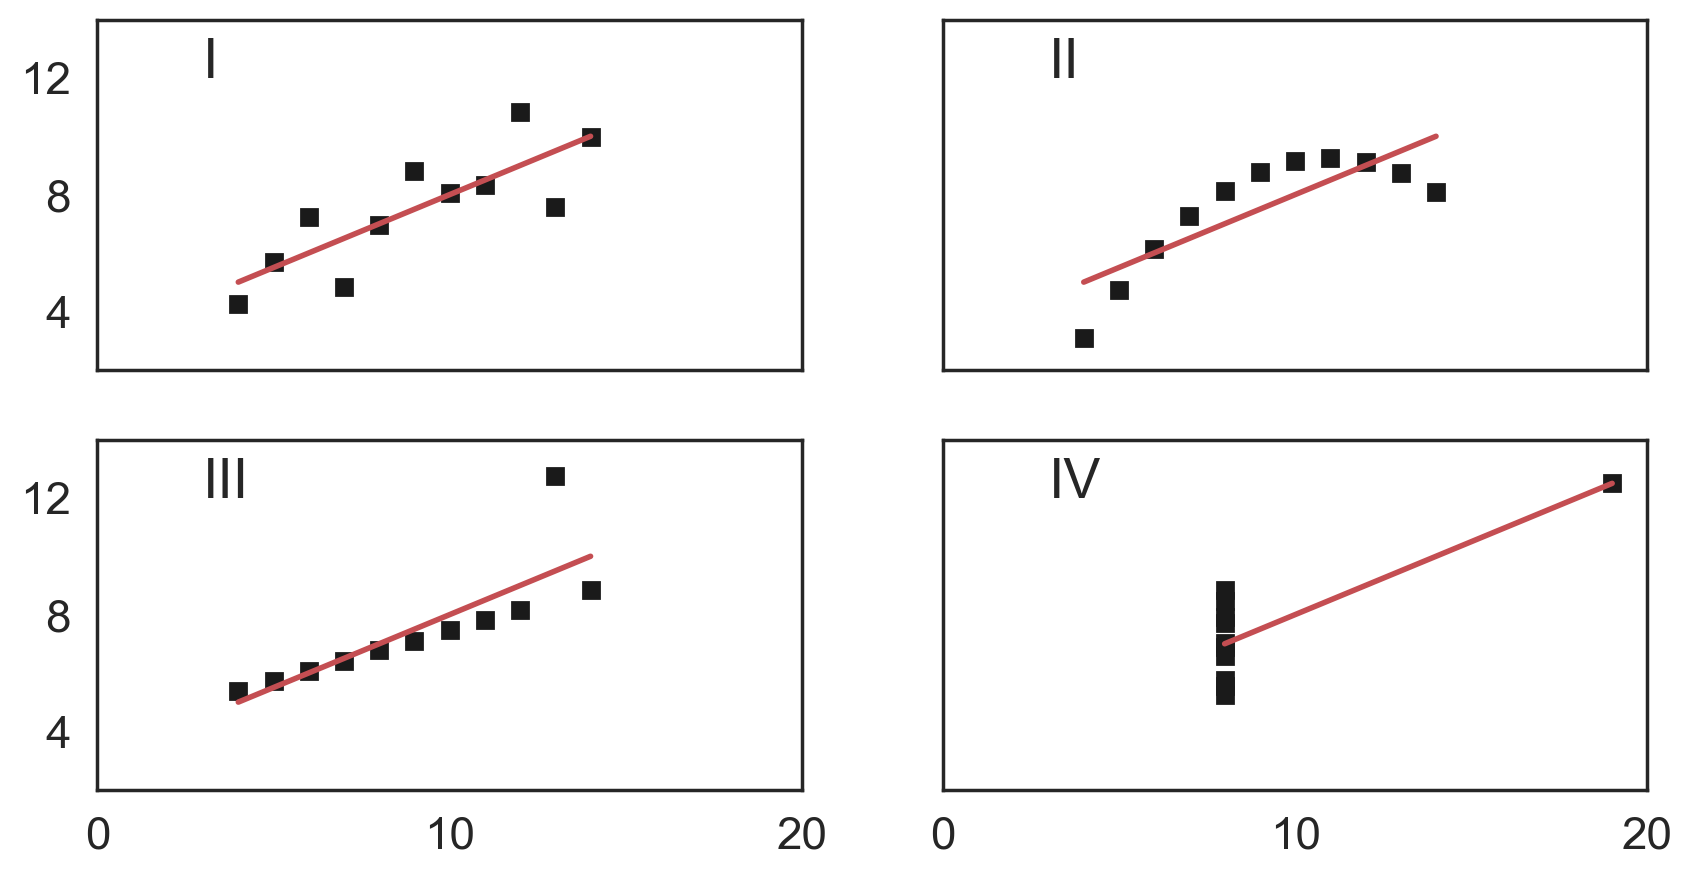

In [22]:
def fit(x):
    return 3 + 0.5 * x

xfit = np.array([np.min(x), np.max(x)])

plt.subplot(221)
plt.plot(x, y1, 'ks', xfit, fit(xfit), 'r-', lw=2)
plt.axis([2, 20, 2, 14])
plt.setp(plt.gca(), xticklabels=[], yticks=(4, 8, 12), xticks=(0, 10, 20))
plt.text(3, 12, 'I', fontsize=20)

plt.subplot(222)
plt.plot(x, y2, 'ks', xfit, fit(xfit), 'r-', lw=2)
plt.axis([2, 20, 2, 14])
plt.setp(plt.gca(), xticks=(0, 10, 20), xticklabels=[],
         yticks=(4, 8, 12), yticklabels=[], )
plt.text(3, 12, 'II', fontsize=20)

plt.subplot(223)
plt.plot(x, y3, 'ks', xfit, fit(xfit), 'r-', lw=2)
plt.axis([2, 20, 2, 14])
plt.text(3, 12, 'III', fontsize=20)
plt.setp(plt.gca(), yticks=(4, 8, 12), xticks=(0, 10, 20))

plt.subplot(224)
xfit = np.array([np.min(x4), np.max(x4)])
plt.plot(x4, y4, 'ks', xfit, fit(xfit), 'r-', lw=2)
plt.axis([2, 20, 2, 14])
plt.setp(plt.gca(), yticklabels=[], yticks=(4, 8, 12), xticks=(0, 10, 20))
plt.text(3, 12, 'IV', fontsize=20)

# verify the stats
pairs = (x, y1), (x, y2), (x, y3), (x4, y4)
for x, y in pairs:
    print('mean=%1.2f, std=%1.2f, r=%1.2f' % (np.mean(y), np.std(y),
          np.corrcoef(x, y)[0][1]))

plt.show()

### Draw the Graph (What a complete EDA is all about!)

## Shape

- range of values
- overall shape
- outliers? 

### Outliers

Outliers are values that fall outside the typical range of your dataset. These can occur for all types of reasons:

- data entry errors
- poor sampling procedures
- technical or mechanical errors
- unexpected changes in weather
- extreme values
- people giving incorrect information
- etc.

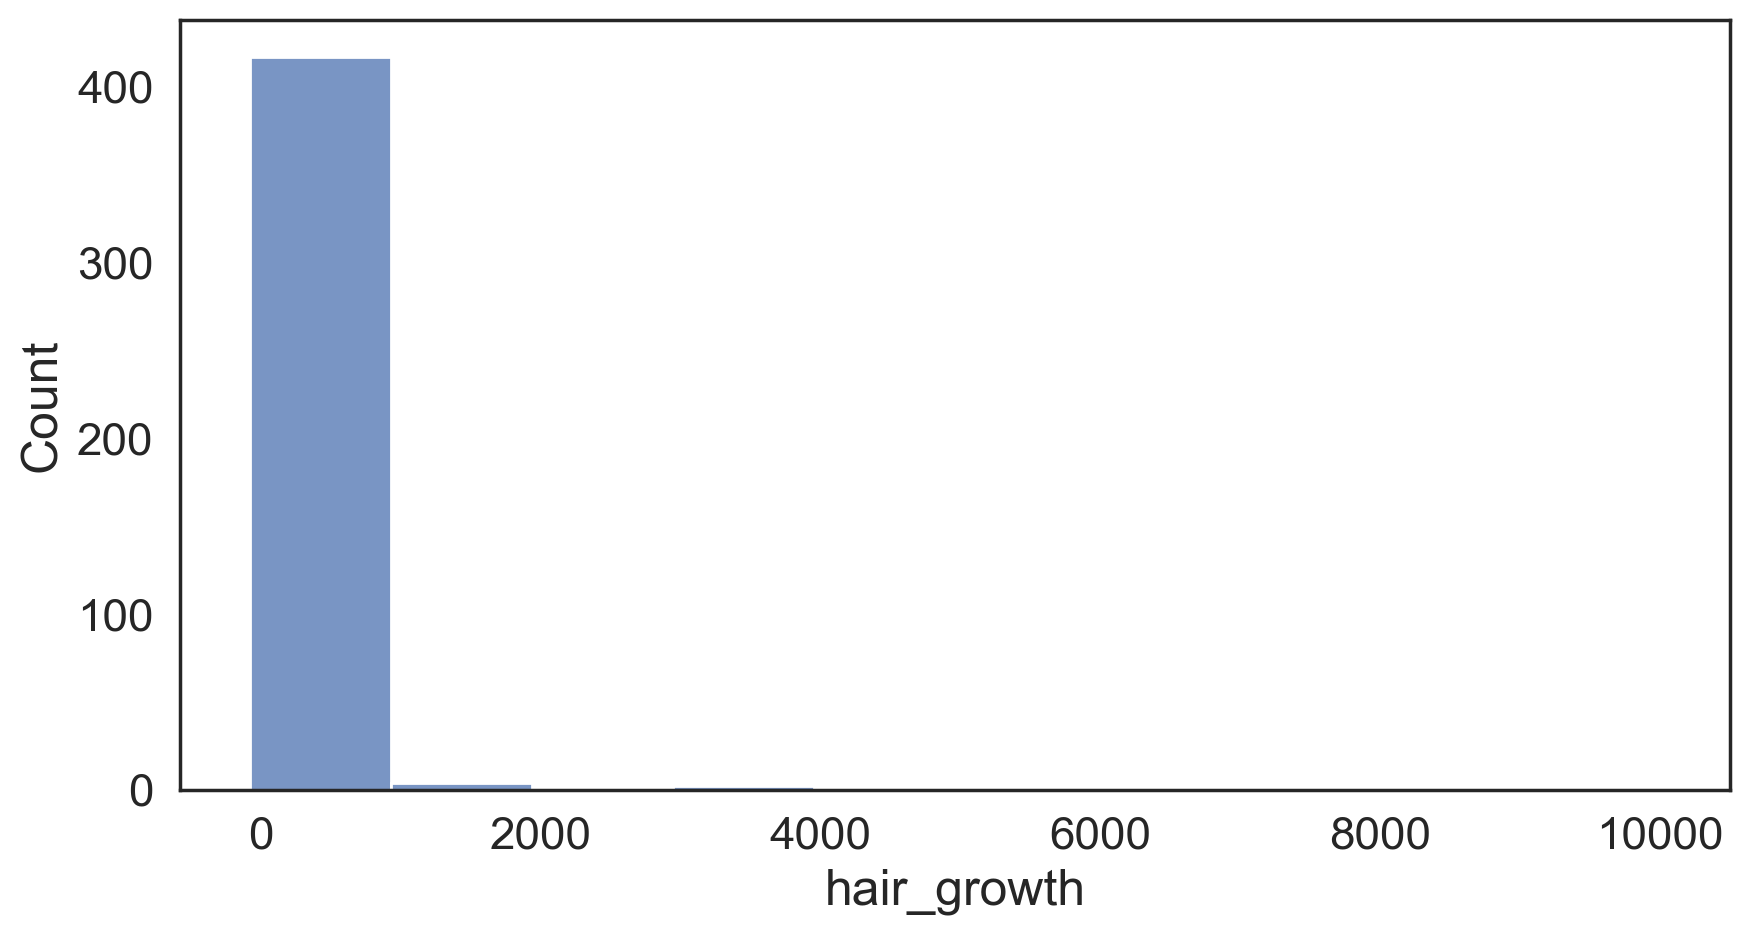

In [23]:
sns.histplot(df['hair_growth'], bins=10);

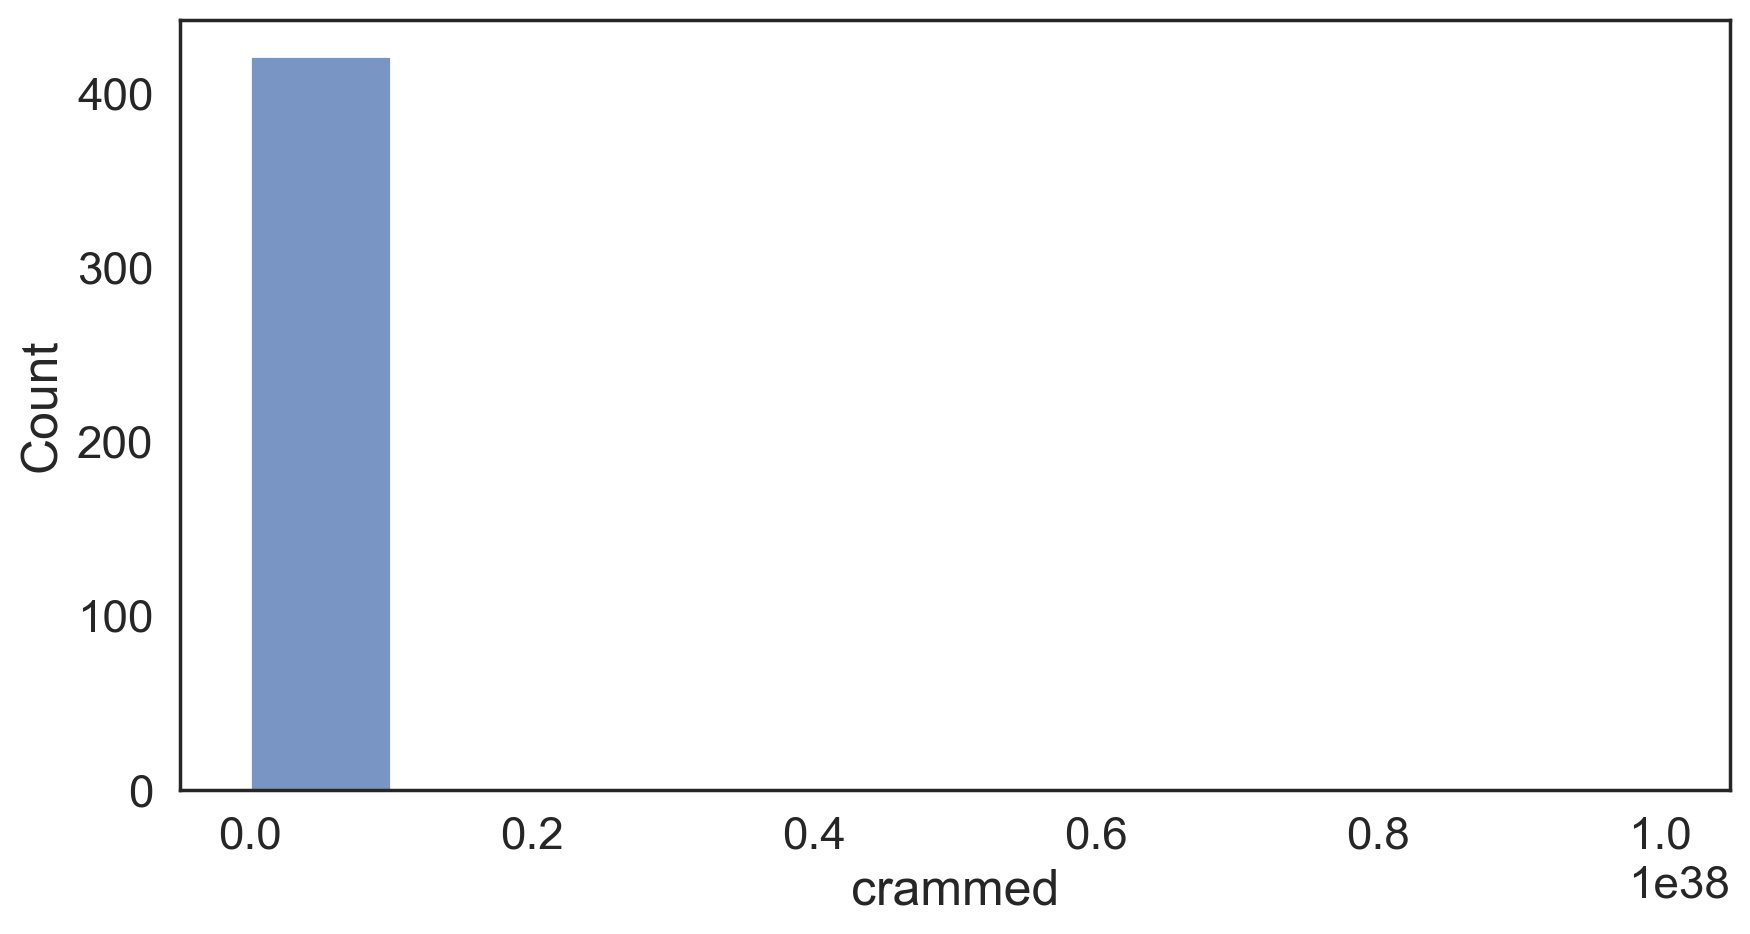

In [24]:
sns.histplot(df['crammed'], bins=10);

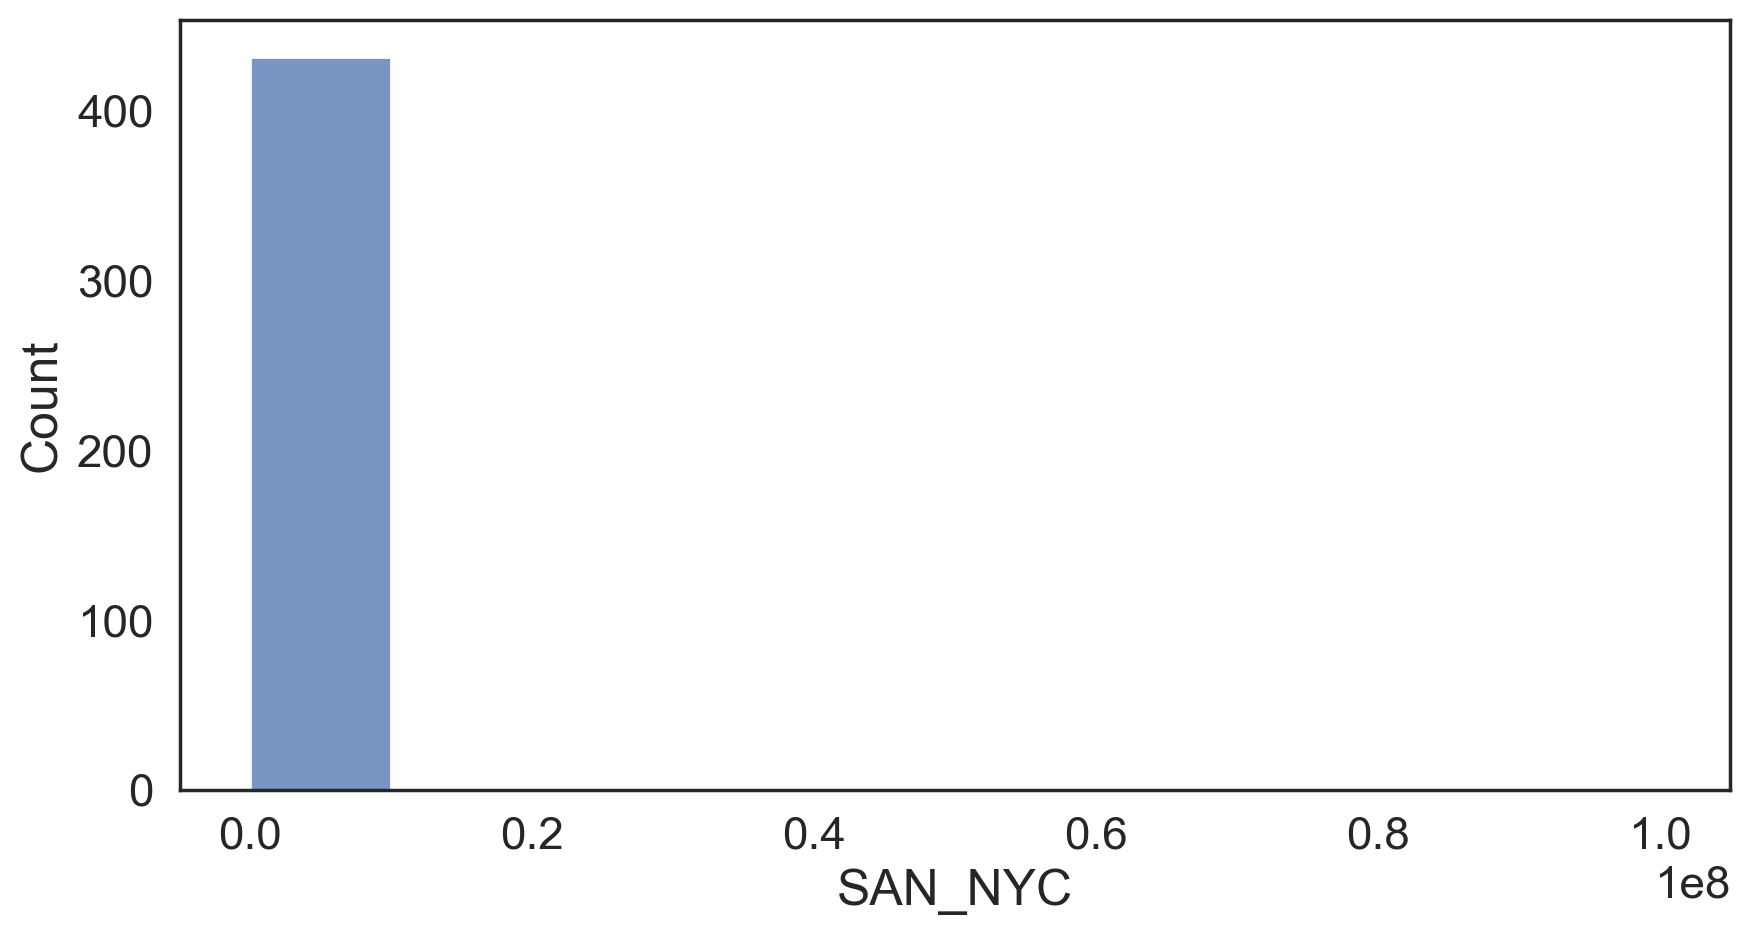

In [25]:
sns.histplot(df['SAN_NYC'], bins=10);

<div class="alert alert-danger">
Caution: Observations should only be removed from your dataset if you have a valid reason to do so. If you remove outliers from your dataset, your report should be <b>very</b> clear that you did so.
</div>

### Question #5 (skipped)

Should we remove any outlier values in this dataset? 

- A) Yes
- B) No
- C) ¯\\\_(ツ)\_/¯

[https://forms.gle/ccZ59BhcbR3KHpYx6](https://forms.gle/ccZ59BhcbR3KHpYx6) 

![](../QRCodes/05_08_03.png)

## Central Tendency

- mean 
- median
- mode

The Central Tendency tells you the 'typical' value for an observation in your dataset.

### Mean


$$ \bar x = \frac{\sum\limits_{i = 1}^N x_i}N  $$


- $x_i$ = ith element of the sample
- $\bar x$ = sample mean
- $N$ = sample size


In [26]:
df['hair_growth'].mean()

76.35945754716981

In [27]:
# check mean for each column
df.mean(numeric_only=True)

hair_growth    7.635946e+01
crammed        2.369668e+35
SAN_NYC        2.588638e+05
dtype: float64

### Median

In [28]:
# check median for each column
df.median()

hair_growth       15.0
crammed        10000.0
SAN_NYC           75.0
dtype: float64

### Median vs. Mean

When the median and mean are not similar to one another...what's the best approach?

In [29]:
# median and mean for same series
print( 'median: ', df['hair_growth'].median())
print( 'mean: ', df['hair_growth'].mean())

median:  15.0
mean:  76.35945754716981


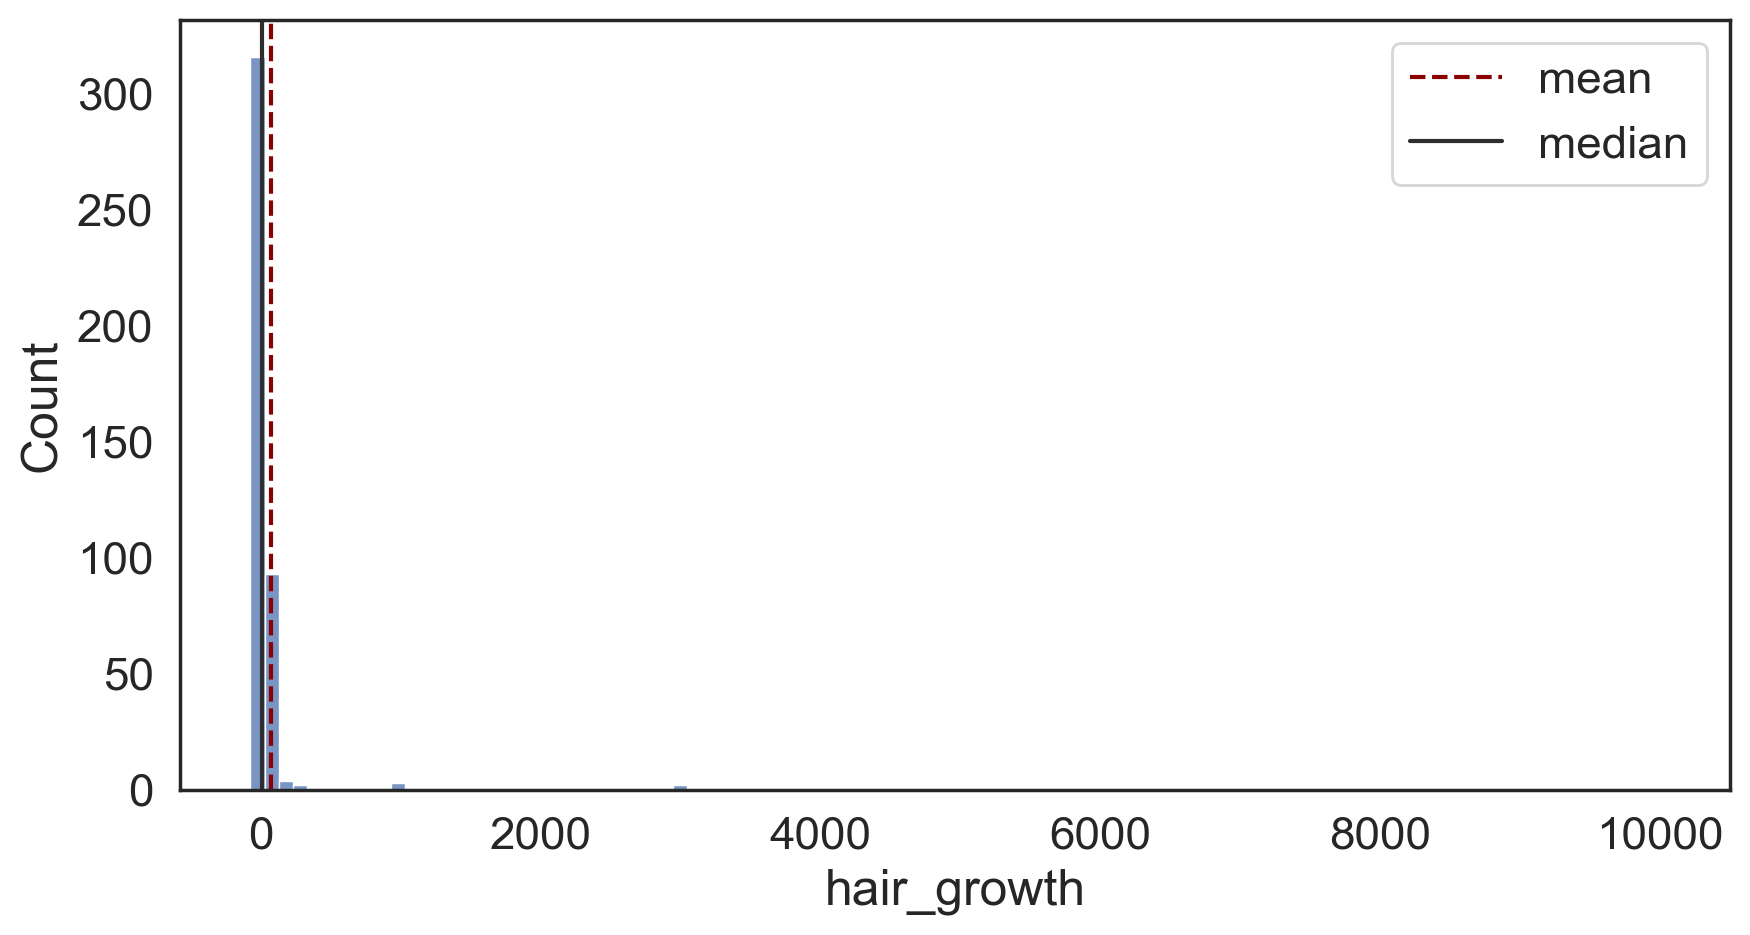

In [30]:
# take a look at it all together
ax = sns.histplot(df['hair_growth'], bins=100  );
ax.axvline(df['hair_growth'].mean(), color='darkred', linestyle='--', label='mean');
ax.axvline(df['hair_growth'].median(), color='#2e2e2e', linestyle='-', label='median')
ax.legend();

### Question #6

Which of the following is the best way to measure the central tendency of `hair_growth` in these data?

- A) mean
- B) median
- C) mode

[https://forms.gle/dCXNPLYsJHHdjHVo6](https://forms.gle/dCXNPLYsJHHdjHVo6)

![](../QRCodes/05_08_04.png)

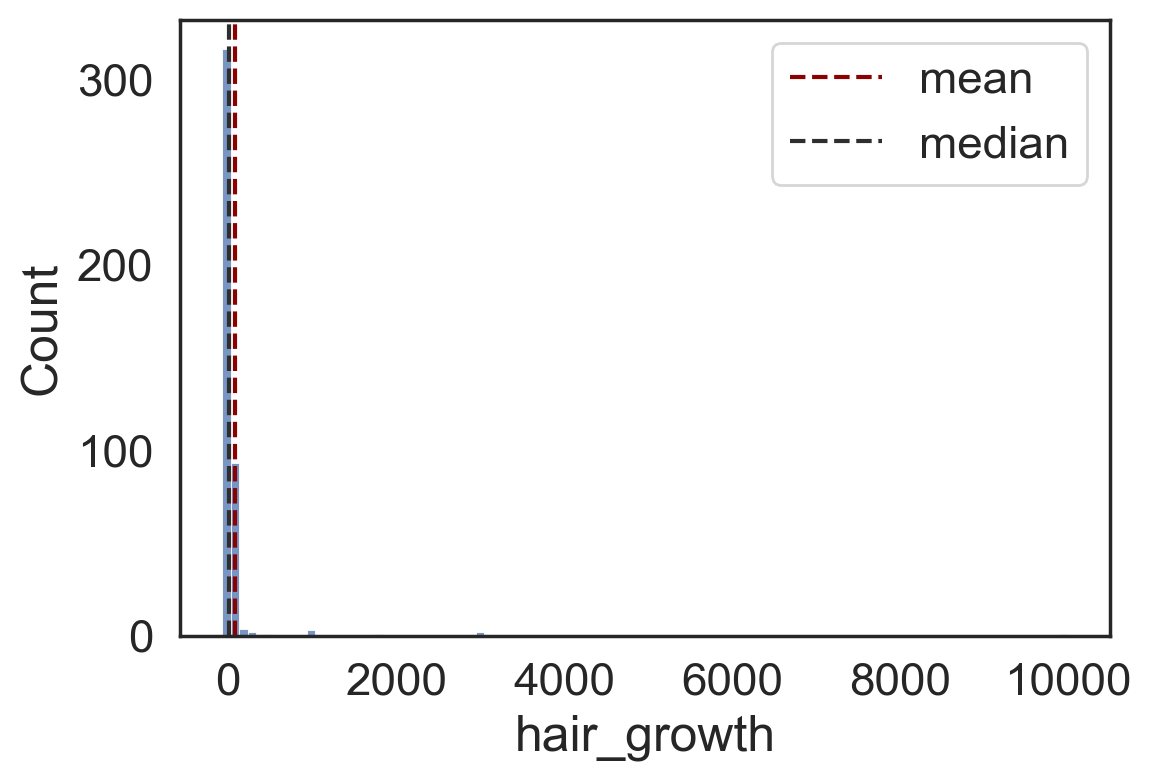

In [34]:
# increase the number of bins here
plt.figure(figsize=(6,4))
ax = sns.histplot(df['hair_growth'], bins=100);
ax.axvline(df['hair_growth'].mean(), color='darkred', linestyle='--', label='mean');
ax.axvline(df['hair_growth'].median(), color='#2e2e2e', linestyle='--', label='median')
ax.legend();

#### How did y'all do?

How well do COGS 108 students estimate the following:
- How fast does human hair grow (cm/yr)?
- If every living person stood crammed together side-by-side, how large of an area would they occupy (km²)?
- How many days would it take to walk from San Diego to New York City (assuming no stopping to fix shoes, apply sunscreen, or for sleeping, eating, or other biological needs)?

In [35]:
# compare to actual value: 15 cm/year (~6 in)
df["hair_growth"].median()

15.0

In [36]:
# compare to actual value: 1,000-10,000 km^2)
df['crammed'].median()

10000.0

In [37]:
# compare to actual value: 38 days)
df['SAN_NYC'].median()

75.0

Calculating the mean and median of your sample is helpful when dealing with **quantitative variables**.

When working with **categorical variables**, knowing the mode is helpful.

### Mode

When working with categorical data, the mode is the most common value in the dataset.

### Aside: Why Central Tendency Doesn't Tell the Whole Story

In [ ]:
# generate two different normal distributions
dist_1 = np.random.normal(5, 2, 1000)
dist_2 = np.random.normal(5, 10, 1000)

In [ ]:
# plot distributions side by side
sns.kdeplot(data=dist_1, label="mean: 5, sd: 2")
sns.kdeplot(data=dist_2, label="mean: 5, sd: 10")
plt.legend();

## Variability

- Range
- IQR 
- Variance & Standard Deviation

### Range

The highest value minus the lowest value.

In [ ]:
# determine the 25th and 75th percentiles
min_val = df['hair_growth'].min()
max_val = df['hair_growth'].max()
range_vals =  max_val - min_val
print(max_val, '-' , min_val,' = ',  range_vals)

### IQR (Interquartile Range)

75th percentile - 25th percentile

In [ ]:
# determine the 25th and 75th percentiles
lower, upper = np.nanpercentile(df['hair_growth'], [25, 75])
lower, upper

In [ ]:
# calculate IQR
iqr = upper - lower
iqr

In [ ]:
# visualizing IQR
sns.boxplot(x='hair_growth', data=df);

### Variance & Standard Deviation

- variance
    - measures how close the values in the distribution are to the middle of the distribution
    - average squared difference of the scores from  the mean
- standard deviation
    - square root of the variance

#### Variance

$$ s^2 = \frac {\sum\limits_{i = 1}^N {\left( {x_i - \bar x} \right)^2 }} {(N-1)} $$

- $s^2$ = sample variance
- $x_i$ = ith element of the sample
- $\bar x$ = mean of the sample
- $N$ = sample size


In [ ]:
# calculate variance using pandas
var = df['hair_growth'].var()
var

#### Standard Deviation
square root of the variance

$$ s = \sqrt {\frac {\sum\limits_{i = 1}^N {\left( {x_i - \bar x} \right)^2 }} {(N-1)}} $$

In [ ]:
np.sqrt(var)

In [ ]:
# calculate variance using pandas
sd = df['hair_growth'].std()
sd 

## Descriptive Tables

Helpful for understanding your data...but not the best explanatory visualization.

In [ ]:
df.describe()

### Final Thoughts:

- If you just wanted to answer those three questions, your analysis would be complete with EDA alone. That said, your projects will require EDA...and additional analyses.
- When doing EDA your plots are to help you understand. Quick and dirty plots are fine. When you are writing a report, that's when you polish up your figures.  